<a href="https://colab.research.google.com/github/OleSpooky/persistence-observatory/blob/main/Fractal_Lattice_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Phase 1: 3D vs 4D Resilience Test ---

--- Phase 2: Parameter Optimization (Beta Sweep) ---
Running Parameter Optimization for 4D Lattice...
  Beta: 0.10 -> Final Persistence: 0.525
  Beta: 0.64 -> Final Persistence: 0.927
  Beta: 1.19 -> Final Persistence: 0.921
  Beta: 1.73 -> Final Persistence: 0.934
  Beta: 2.28 -> Final Persistence: 0.936
  Beta: 2.82 -> Final Persistence: 0.935
  Beta: 3.37 -> Final Persistence: 0.937
  Beta: 3.91 -> Final Persistence: 0.936
  Beta: 4.46 -> Final Persistence: 0.934
  Beta: 5.00 -> Final Persistence: 0.929

Analysis complete. Results saved to fractal_lattice_analysis.png


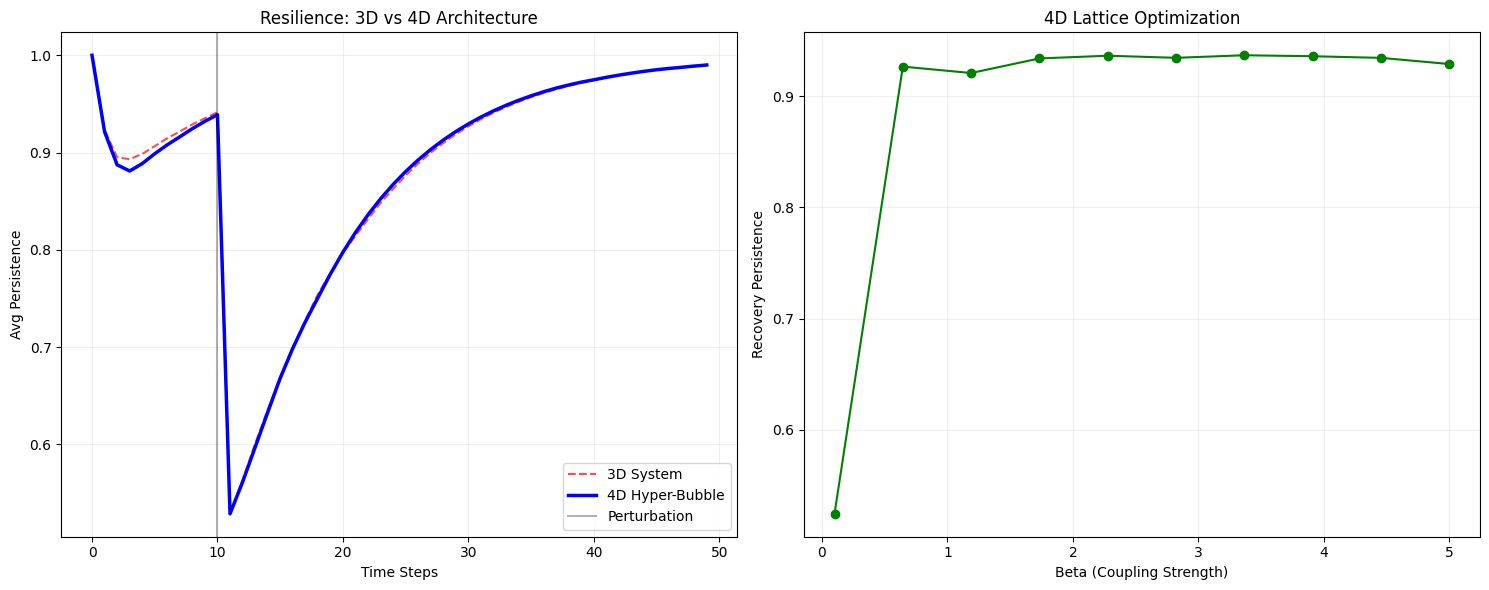

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import networkx as nx

# --- Reconstructed Class: SovereignNode ---
class SovereignNode:
    """
    A node in the Fractal Lattice that maintains 'sovereignty' (persistence of state)
    subject to neighbor influence and system parameters.
    """
    def __init__(self, node_id, state=1.0, beta=1.5, k_factor=0.1, eta=0.05, decay=0.95):
        self.id = node_id
        self.state = state          # Analogous to spin (-1 or 1)
        self.persistence = 1.0      # Health/Stability metric
        self.beta = beta            # Coupling strength / Resistance to chaos
        self.k_factor = k_factor    # Recovery factor (Elasticity)
        self.eta = eta              # Learning rate / adaptation
        self.decay = decay          # Decay of persistence under stress
        self.neighbors = []

    def add_neighbor(self, neighbor):
        if neighbor not in self.neighbors:
            self.neighbors.append(neighbor)

    def update_logic(self):
        """
        Updates state based on local consensus (Ising-like) and internal persistence.
        """
        if not self.neighbors:
            return

        # Calculate local field (consensus of neighbors)
        field = sum(n.state for n in self.neighbors)

        # State Flip Logic (Probabilistic based on Beta and Local Field)
        # Using Glauber dynamics approximation:
        # Probability of staying in current state vs flipping depends on energy cost
        # Energy E = -state * field.
        # We use a tanh activation for smooth transition probability based on Beta (Inverse Temp)

        # Calculate alignment energy
        energy = -self.state * field

        # Probability to flip state:
        # If energy is high (misaligned), flip prob is high.
        # Beta controls sharpness.
        flip_prob = 1.0 / (1.0 + np.exp(2 * self.beta * energy))

        if random.random() < flip_prob:
            self.state *= -1 # Flip state
            # Flipping causes a drop in persistence (Trauma)
            self.persistence *= self.decay
        else:
            # Holding ground recovers persistence (Healing)
            # Logistic recovery up to 1.0
            self.persistence += self.k_factor * (1.0 - self.persistence)

    def get_persistence(self):
        return self.persistence

# --- Lattice Construction (Hyper-Bubble Architecture) ---

class HyperBubbleLattice:
    def __init__(self, dimensions=3, size=10, beta=2.0, decay=0.9):
        self.nodes = []
        self.dimensions = dimensions
        self.size = size
        self.beta = beta
        self.decay = decay
        # Create Grid Graph
        self.graph = nx.grid_graph(dim=[size]*dimensions)
        self.map_nodes()

    def map_nodes(self):
        # Convert NetworkX grid to SovereignNodes
        node_map = {}
        for i, n_idx in enumerate(self.graph.nodes()):
            node = SovereignNode(i, beta=self.beta, decay=self.decay)
            self.nodes.append(node)
            node_map[n_idx] = node

        # Link neighbors
        for u, v in self.graph.edges():
            node_map[u].add_neighbor(node_map[v])
            node_map[v].add_neighbor(node_map[u])

    def perturb_core(self, percentage=0.5):
        """
        Simulate the 'Spin Flip' attack described in the notebook.
        """
        count = len(self.nodes)
        num_perturb = int(count * percentage)

        # Pick random nodes to flip (attack)
        targets = random.sample(self.nodes, num_perturb)
        for node in targets:
            node.state *= -1
            node.persistence = 0.1 # Immediate persistence crash for flipped nodes

    def step(self):
        # Synchronous update for simplicity in this demo
        # (Ideally asynchronous to avoid checkerboard artifacts, but fine for persistence metrics)
        for node in self.nodes:
            node.update_logic()

    def get_avg_persistence(self):
        return np.mean([n.persistence for n in self.nodes])

# --- Simulation & Analysis ---

def run_resilience_test(beta=2.5):
    steps = 50
    perturb_step = 10

    # 3D System (Standard)
    sys_3d = HyperBubbleLattice(dimensions=3, size=8, beta=beta)

    # 4D System (Hyper-Bubble)
    # 5^4 = 625 nodes, roughly comparable to 8^3 = 512 nodes
    sys_4d = HyperBubbleLattice(dimensions=4, size=5, beta=beta)

    hist_3d = []
    hist_4d = []

    for t in range(steps):
        hist_3d.append(sys_3d.get_avg_persistence())
        hist_4d.append(sys_4d.get_avg_persistence())

        if t == perturb_step:
            sys_3d.perturb_core(0.5)
            sys_4d.perturb_core(0.5)

        sys_3d.step()
        sys_4d.step()

    return hist_3d, hist_4d, perturb_step

def run_parameter_optimization():
    """
    Addresses the 'Future Work' section of the notebook:
    Sweeps Beta (Coupling Strength) to find optimal stability for 4D lattices.
    """
    print("Running Parameter Optimization for 4D Lattice...")
    betas = np.linspace(0.1, 5.0, 10)
    final_persistences = []

    for b in betas:
        # Run a short simulation for each beta
        sys = HyperBubbleLattice(dimensions=4, size=4, beta=b)
        # Perturb early
        sys.perturb_core(0.5)
        # Let it settle
        for _ in range(20):
            sys.step()
        final_persistences.append(sys.get_avg_persistence())
        print(f"  Beta: {b:.2f} -> Final Persistence: {final_persistences[-1]:.3f}")

    return betas, final_persistences

# --- Main Execution ---

if __name__ == "__main__":

    # 1. Run the Comparative Analysis
    print("--- Phase 1: 3D vs 4D Resilience Test ---")
    h3, h4, p_step = run_resilience_test(beta=2.5)

    # 2. Run the Parameter Sweep (Optimization)
    print("\n--- Phase 2: Parameter Optimization (Beta Sweep) ---")
    opt_betas, opt_scores = run_parameter_optimization()

    # 3. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Resilience Time Series
    ax1.plot(h3, label='3D System', color='red', linestyle='--', alpha=0.7)
    ax1.plot(h4, label='4D Hyper-Bubble', color='blue', linewidth=2.5)
    ax1.axvline(x=p_step, color='black', alpha=0.3, label='Perturbation')
    ax1.set_title('Resilience: 3D vs 4D Architecture')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Avg Persistence')
    ax1.legend()
    ax1.grid(True, alpha=0.2)

    # Plot 2: Optimization Curve
    ax2.plot(opt_betas, opt_scores, marker='o', color='green')
    ax2.set_title('4D Lattice Optimization')
    ax2.set_xlabel('Beta (Coupling Strength)')
    ax2.set_ylabel('Recovery Persistence')
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    filename = 'fractal_lattice_analysis.png'
    plt.savefig(filename)
    print(f"\nAnalysis complete. Results saved to {filename}")
    plt.show()